# Парсинг вакансий

🔎***Какие позиции ищем:***


*   Ветеринарный врач
*   Ассистент ветеринарного врача
* Грумер
* Зооняня/догситтер
* Кинолог
* Администратор


---






Во-первых, статический парсинг вакансий, связанных с уходом за животными, на странице тг канала rabota_moskva.

In [15]:
import re
import time
import requests
import pandas as pd

from bs4 import BeautifulSoup
from urllib.parse import urljoin

In [16]:
class TelegramVacancyParser:
    def __init__(self, channel_name, delay = 1.0):
        self.channel_name = channel_name
        self.base_url = f"https://t.me/s/{channel_name}"
        self.delay = delay

        self.headers = {
            "User-Agent": (
                "Mozilla/5.0 (Windows NT 10.0; Win64; x64) "
                "AppleWebKit/537.36 (KHTML, like Gecko) "
                "Chrome/124.0 Safari/537.36"
            )
        }

        self.pet_keywords = re.compile(
            r"ветеринар|ветклиник|вет\.?клиник|грумер|зоосалон|"
            r"зоонян|котоотел|отель для кош|уход.*кош|уход.*животн|"
            r"собак|кошк|животн|питомц",
            re.IGNORECASE
        )

        self.vacancy_keywords = re.compile(
            r"требуется|ищем|ищет|нужен|нужна|приглашаем|"
            r"вакансия|з/п|зарплата|оклад|оплата|график",
            re.IGNORECASE
        )

        self.bad_keywords = re.compile(
            r"домработниц|семейная пара|помощниц[аы] по хозяйству|"
            r"агроном|декоративных растений|питомник декоративных растений|"
            r"сельскохозяйственных животных|кормовых добавок|"
            r"оператор call-центра|call-центр|"
            r"сбор денег|пожертвован|помощь приюту|"
            r"редактор|маркетолог|продажам кормовых добавок",
            re.IGNORECASE
        )

    def fetch_page(self, query = None, before = None):
        params = {}

        if query:
            params["q"] = query

        if before:
            params["before"] = before

        response = requests.get(self.base_url, params=params, headers=self.headers, timeout=20)

        response.raise_for_status()

        return BeautifulSoup(response.text, "lxml")

    def get_next_before(self, soup):
        more_link = soup.find("a", class_="tme_messages_more")

        if not more_link:
            return None

        href = more_link.get("href", "")

        match = re.search(r"before=(\d+)", href)

        if match:
            return match.group(1)

        return None

    def normalize_text(self, text):
        text = text.replace("\xa0", " ")
        text = re.sub(r"[ \t]+", " ", text)
        text = re.sub(r"\n{3,}", "\n\n", text)
        return text.strip()

    def extract_messages(self, soup, query = None):
        rows = []

        messages = soup.find_all("div", class_="tgme_widget_message")

        for message in messages:
            text_block = message.find("div", class_="tgme_widget_message_text")

            if not text_block:
                continue

            raw_text = text_block.get_text("\n", strip=True)
            raw_text = self.normalize_text(raw_text)

            if not raw_text:
                continue

            link_tag = message.find("a", class_="tgme_widget_message_date")
            post_url = urljoin("https://t.me", link_tag.get("href")) if link_tag else None

            rows.append({"post_url": post_url, "raw_text": raw_text, "search_query": query})

        return rows

    def is_relevant_pet_vacancy(self, text):
        if not self.pet_keywords.search(text):
            return False

        if not self.vacancy_keywords.search(text):
            return False

        if self.bad_keywords.search(text):
            return False

        return True

    def normalize_position(self, text):
        text_lower = text.lower()

        if "ветеринарный врач" in text_lower or "ветврач" in text_lower:
            return "Ветеринарный врач"

        if "ассистент" in text_lower and "ветеринар" in text_lower:
            return "Ассистент ветеринарного врача"

        if "грумер" in text_lower:
            return "Грумер"

        if "администратор" in text_lower and ("ветеринар" in text_lower or "ветклиник" in text_lower):
            return "Администратор ветеринарной клиники"

        if "администратор" in text_lower and "зоосалон" in text_lower:
            return "Администратор зоосалона"

        if (
            "зооняня" in text_lower
            or "догситтер" in text_lower
            or "отель для собак" in text_lower
            or "уходу за собаками" in text_lower
            or "уход за собаками" in text_lower
            or "котоотель" in text_lower
            or "отель для кош" in text_lower
            or "уходу за кошками" in text_lower
            or "уход за кошками" in text_lower
        ):
            return "Зооняня"

        if "уходу за животными" in text_lower or "уход за животными" in text_lower:
            return "Сотрудник по уходу за животными"

        return None

    def money_to_rub(self, number, unit):
        number = number.replace(" ", "").replace("\xa0", "")

        if re.fullmatch(r"\d{1,3}(?:\.\d{3})+", number):
            number = number.replace(".", "")

        value = float(number.replace(",", "."))

        if unit:
            unit = unit.lower()

            if "тыс" in unit or "тысяч" in unit or unit in ["к", "k"]:
                value *= 1000

        return int(value)

    def extract_salary(self, text):
        salary_data = {"salary_text": None, "salary_min_rub": None, "salary_max_rub": None}

        text_for_search = re.sub(r"\b\d{1,2}[:.]\d{2}\b", "", text)

        number = r"\d{1,3}(?:[\s\xa0.]?\d{3})+|\d+(?:[,.]\d+)?"
        unit = r"тыс\.?|тысяч|к|k"

        candidate_lines = []

        for line in text_for_search.split("\n"):
            if re.search(r"з/п|зарплат|оклад|оплат|доход|ставка|₽|руб|р\b", line, re.IGNORECASE):
                candidate_lines.append(line)

        if not candidate_lines:
            return salary_data

        salary_text_source = "\n".join(candidate_lines)

        range_pattern = re.compile(
            rf"(?P<prefix>от)?\s*"
            rf"(?P<num1>{number})\s*"
            rf"(?P<unit1>{unit})?\s*"
            rf"(?:₽|руб\.?|рублей|рубля|р\b)?\s*"
            rf"(?:[-–—]|\s+до\s+)\s*"
            rf"(?P<num2>{number})\s*"
            rf"(?P<unit2>{unit})?\s*"
            rf"(?:₽|руб\.?|рублей|рубля|р\b)?",
            re.IGNORECASE
        )

        range_match = range_pattern.search(salary_text_source)

        if range_match:
            unit1 = range_match.group("unit1") or range_match.group("unit2")
            unit2 = range_match.group("unit2") or range_match.group("unit1")

            value1 = self.money_to_rub(range_match.group("num1"), unit1)
            value2 = self.money_to_rub(range_match.group("num2"), unit2)

            if max(value1, value2) < 1000:
                return salary_data

            salary_data["salary_text"] = range_match.group(0).strip()
            salary_data["salary_min_rub"] = min(value1, value2)
            salary_data["salary_max_rub"] = max(value1, value2)

            return salary_data

        single_pattern = re.compile(
            rf"(?P<prefix>от|до)?\s*"
            rf"(?P<num1>{number})\s*"
            rf"(?P<unit1>{unit})?\s*"
            rf"(?:₽|руб\.?|рублей|рубля|р\b)?",
            re.IGNORECASE
        )

        matches = list(single_pattern.finditer(salary_text_source))

        for match in matches:
            value = self.money_to_rub(match.group("num1"), match.group("unit1"))

            if value < 1000:
                continue

            salary_data["salary_text"] = match.group(0).strip()

            prefix = match.group("prefix")

            if prefix and prefix.lower() == "от":
                salary_data["salary_min_rub"] = value

            elif prefix and prefix.lower() == "до":
                salary_data["salary_max_rub"] = value

            else:
                salary_data["salary_min_rub"] = value
                salary_data["salary_max_rub"] = value

            return salary_data

        return salary_data

    def parse_record(self, row):
        text = row["raw_text"]

        salary = self.extract_salary(text)

        parsed = {
            **row,
            "position": self.normalize_position(text),
            "salary_text": salary["salary_text"],
            "salary_min_rub": salary["salary_min_rub"],
            "salary_max_rub": salary["salary_max_rub"]
            }

        return parsed

    def collect_by_queries(self, queries, pages_per_query = 5):
        all_rows = []

        for query in queries:
            before = None

            for page_num in range(pages_per_query):
                soup = self.fetch_page(query=query, before=before)

                rows = self.extract_messages(soup, query=query)
                all_rows.extend(rows)

                before = self.get_next_before(soup)

                if not before:
                    break

                time.sleep(self.delay)

            time.sleep(self.delay)

        return self.build_dataframe(all_rows)


    def build_dataframe(self, rows):
        unique = {}

        for row in rows:
            key = row["post_url"] or row["raw_text"][:100]
            unique[key] = row

        relevant_rows = [self.parse_record(row) for row in unique.values() if self.is_relevant_pet_vacancy(row["raw_text"])]

        df = pd.DataFrame(relevant_rows)

        if df.empty:
            return df

        df = df.dropna(subset=["position"])

        return df.reset_index(drop=True)




In [ ]:
queries = [
    "груминг",
    "грумер",
    "ветеринар",
    "ветклиника",
    "ассистент ветеринарного врача",
    "зоосалон",
    "зооняня",
    "администратор зоосалона",
    "администратор ветеринарной клиники",
    "догситтер",
    "котоотель",
    "отель для кош",
    "отель для собак",
    "уход за животными",
    "уход за собаками",
    "уход за кошками",
    "животные",
    "зоогостиниц"
]

parser = TelegramVacancyParser(channel_name="rabota_moskva", delay=1.0)

telegram_df = parser.collect_by_queries(queries=queries, pages_per_query=5)

telegram_df = telegram_df.drop_duplicates(subset=["position", "salary_text", "raw_text"], keep="first").reset_index(drop=True)

telegram_df.to_csv("telegram_vacancies.csv", index=False, encoding="utf-8-sig")

In [ ]:
display(telegram_df)

,post_url,raw_text,search_query,position,salary_text,salary_min_rub,salary_max_rub
0,https://t.me/rabota_moskva/443,Требуется\nгрумер\nв салон\nТребования:\n•Стаж...,грумер,Грумер,None,NaN,NaN
1,https://t.me/rabota_moskva/180,Грумер\nТребования: опыт работы с собаками раз...,уход за кошками,Грумер,None,NaN,NaN
2,https://t.me/rabota_moskva/4234,В\nзоосалон\n«Тесси» требуется грумер с опытом...,зоосалон,Грумер,от 80000,80000.0,NaN
3,https://t.me/rabota_moskva/12356,"Всем привет!\nС радостью сообщаем, что в нашей...",грумер,Грумер,80.000,80000.0,80000.0
4,https://t.me/rabota_moskva/14402,Грумер\n70 000 ₽\nОбязанности:\n• модельные ст...,животные,Грумер,70 000 ₽,70000.0,70000.0
5,https://t.me/rabota_moskva/5270,Ветеринарный консультант (м. Пражская)\nот 350...,ассистент ветеринарного врача,Ассистент ветеринарного врача,от 35000 до 49000 руб.,35000.0,49000.0
6,https://t.me/rabota_moskva/8970,Ассистент ветеринарного врача\nЗ/п от 45 000р ...,уход за животными,Ассистент ветеринарного врача,от 45 000р до 70 000р,45000.0,70000.0
7,https://t.me/rabota_moskva/12053,Администратор\nветеринарной\nклиники\n60 000 ₽...,администратор ветеринарной клиники,Администратор ветеринарной клиники,60 000 ₽,60000.0,60000.0
8,https://t.me/rabota_moskva/2283,Требуется\nадминистратор\nветеринарной\nклиник...,администратор ветеринарной клиники,Администратор ветеринарной клиники,от 2500 руб.,2500.0,NaN
9,https://t.me/rabota_moskva/11742,Ассистент\nветеринарного\nврача\n2500 ₽/смена\...,ассистент ветеринарного врача,Ассистент ветеринарного врача,2500 ₽,2500.0,2500.0


Во-вторых, динамический парсинг вакансий на hh.ru с помощью Selenium.

(Код с парсингом вакансий в файле `hh_ru_selenium_parsing.py`, а очистка датафрейма в файле `hh_vacancies_clean.py`, в итоге получился датафрейм `hh_pet_vacancies_clean_salary.csv`, импортируем его сюда.)

In [17]:
from google.colab import files

uploaded = files.upload()

Saving hh_pet_vacancies_clean_salary.csv to hh_pet_vacancies_clean_salary.csv


In [18]:
hh_df = pd.read_csv("hh_pet_vacancies_clean_salary.csv", encoding="utf-8-sig")

hh_df.head()

,title,position_group,company,salary_line_extracted,salary_min_rub,salary_max_rub
0,Администратор в груминг салон,Администратор pet-сервиса,DOODLES,"70 000 – 80 000 ₽ за месяц, на руки",70000.0,80000.0
1,Администратор в груминг-салон,Администратор pet-сервиса,Businka,"70 000 – 80 000 ₽ за месяц, на руки",70000.0,80000.0
2,Администратор в груминг салон,Администратор pet-сервиса,ИП Сушков Александр Евгеньевич,"55 000 – 75 000 ₽ за месяц, на руки",55000.0,75000.0
3,Администратор зоосалона (груминг),Администратор pet-сервиса,Груминг салон me my,"от 40 000 ₽ за месяц, на руки",40000.0,NaN
4,Администратор Груминг студии,Администратор pet-сервиса,Вальтер,"60 000 – 80 000 ₽ за месяц, до вычета налогов",60000.0,80000.0


Надо объединить эти датафреймы.

In [19]:
telegram_part = telegram_df[["position", "salary_min_rub", "salary_max_rub"]].copy()

telegram_part["position"] = telegram_part["position"].replace({"Администратор ветеринарной клиники": "Администратор pet-сервиса"})

hh_part = hh_df[["position_group", "salary_min_rub", "salary_max_rub"]].copy()

hh_part = hh_part.rename(columns={"position_group": "position"})

combined_df = pd.concat([telegram_part, hh_part], ignore_index=True)

combined_df = combined_df.dropna(subset=["salary_min_rub"]).reset_index(drop=True)

combined_df.to_csv("combined_vacancies_salary.csv", index=False, encoding="utf-8-sig")

print("Размер объединённого датафрейма:", combined_df.shape)

print(combined_df.head(20))

Размер объединённого датафрейма: (598, 3)
                         position  salary_min_rub  salary_max_rub
0                          Грумер         80000.0             NaN
1                          Грумер         80000.0         80000.0
2                          Грумер         70000.0         70000.0
3   Ассистент ветеринарного врача         35000.0         49000.0
4   Ассистент ветеринарного врача         45000.0         70000.0
5       Администратор pet-сервиса         60000.0         60000.0
6       Администратор pet-сервиса          2500.0             NaN
7   Ассистент ветеринарного врача          2500.0          2500.0
8   Ассистент ветеринарного врача        200000.0        200000.0
9   Ассистент ветеринарного врача          2500.0             NaN
10              Ветеринарный врач        200000.0        200000.0
11                        Зооняня         36000.0         40000.0
12      Администратор pet-сервиса         45000.0         60000.0
13      Администратор pet-сервиса 

Какие должности получились:

In [20]:
print(combined_df["position"].value_counts())

position
Ассистент ветеринарного врача    182
Ветеринарный врач                165
Грумер                           124
Администратор pet-сервиса        113
Догситтер                          7
Кинолог                            4
Зооняня                            3
Name: count, dtype: int64


Теперь нужно отфильтровать вакансии, где указана зп за смену. Переведем ее в месячную зп, взяв количество смен в месяц = 15.

In [21]:
SHIFT_COUNT_PER_MONTH = 15

filtered_df = combined_df.copy()

mask_shift_salary = ((filtered_df["salary_max_rub"].notna() & (filtered_df["salary_max_rub"] <= 10000)) | (filtered_df["salary_max_rub"].isna() & filtered_df["salary_min_rub"].notna() & (filtered_df["salary_min_rub"] <= 10000)))

filtered_df.loc[mask_shift_salary, ["salary_min_rub", "salary_max_rub"]] = (filtered_df.loc[mask_shift_salary, ["salary_min_rub", "salary_max_rub"]] * SHIFT_COUNT_PER_MONTH)

filtered_df["salary_max_rub"] = filtered_df["salary_max_rub"].fillna(filtered_df["salary_min_rub"])

print("Количество пересчитанных сменных зарплат:", mask_shift_salary.sum())

filtered_df = filtered_df.sort_values(by="salary_min_rub", ascending=True).reset_index(drop=True)

filtered_df.to_csv("combined_vacancies_salary_clean.csv", index=False, encoding="utf-8-sig")


Количество пересчитанных сменных зарплат: 40


✅***Итоговый датафрейм должность - зарплата:***

In [22]:
display(filtered_df)

,position,salary_min_rub,salary_max_rub
0,Догситтер,5000.0,30000.0
1,Грумер,10000.0,80000.0
2,Грумер,10000.0,80000.0
3,Догситтер,14000.0,42000.0
4,Ассистент ветеринарного врача,15000.0,15000.0
...,...,...,...
593,Ветеринарный врач,200000.0,200000.0
594,Ветеринарный врач,250000.0,250000.0
595,Ветеринарный врач,250000.0,250000.0
596,Ветеринарный врач,250000.0,250000.0


# Анализ полученных данных

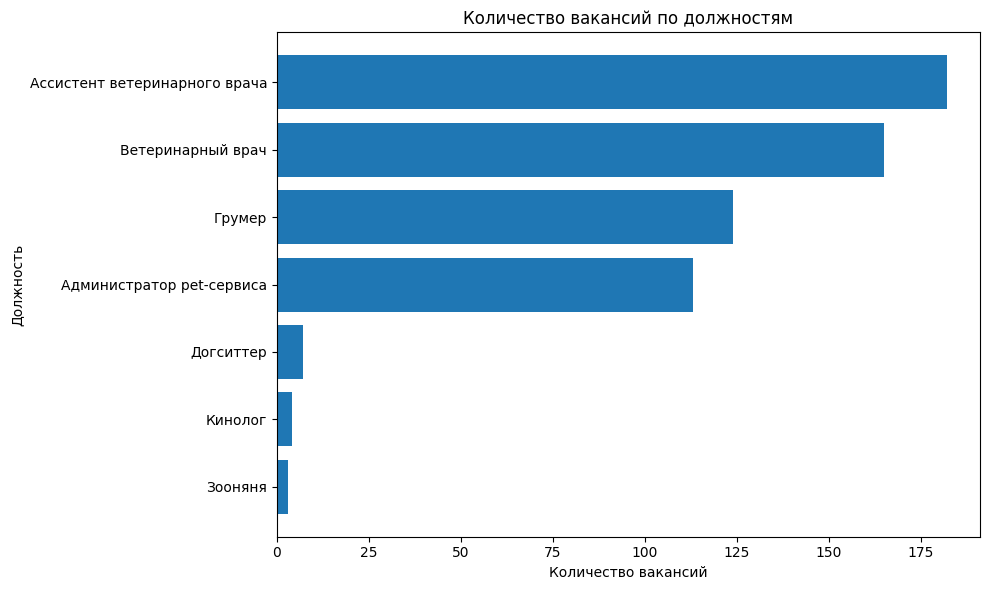

In [23]:
import matplotlib.pyplot as plt

df = filtered_df.copy()

df["salary_avg_rub"] = (df["salary_min_rub"] + df["salary_max_rub"]) / 2

position_counts = (df["position"].value_counts().sort_values(ascending=True))

plt.figure(figsize=(10, 6))
plt.barh(position_counts.index, position_counts.values)
plt.title("Количество вакансий по должностям")
plt.xlabel("Количество вакансий")
plt.ylabel("Должность")
plt.tight_layout()
plt.show()

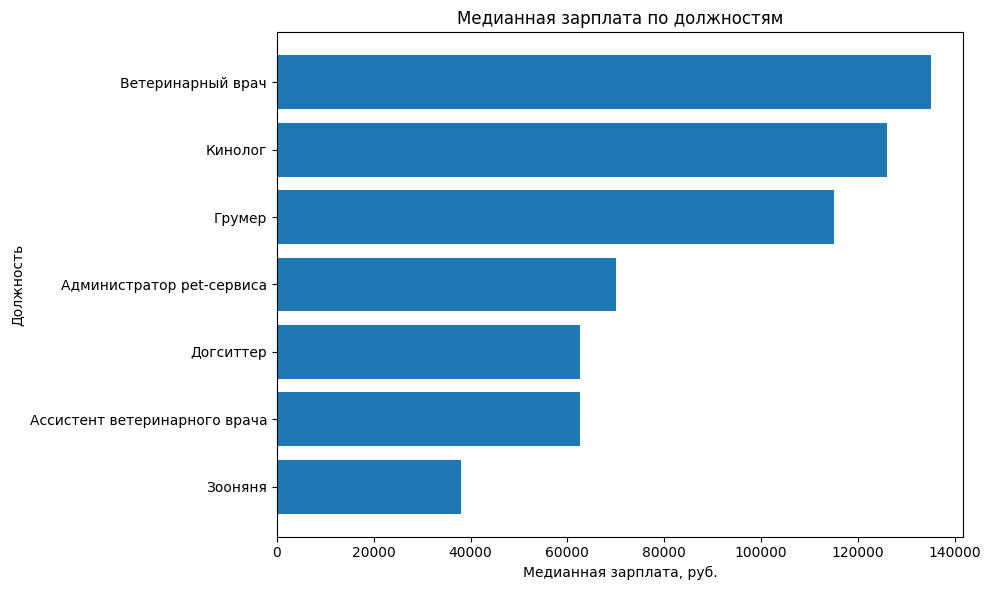

In [25]:
salary_median = (df.groupby("position", as_index=False).agg(salary_median=("salary_avg_rub", "median")).sort_values("salary_median", ascending=True))

plt.figure(figsize=(10, 6))
plt.barh(salary_median["position"], salary_median["salary_median"])
plt.title("Медианная зарплата по должностям")
plt.xlabel("Медианная зарплата, руб.")
plt.ylabel("Должность")
plt.tight_layout()
plt.show()

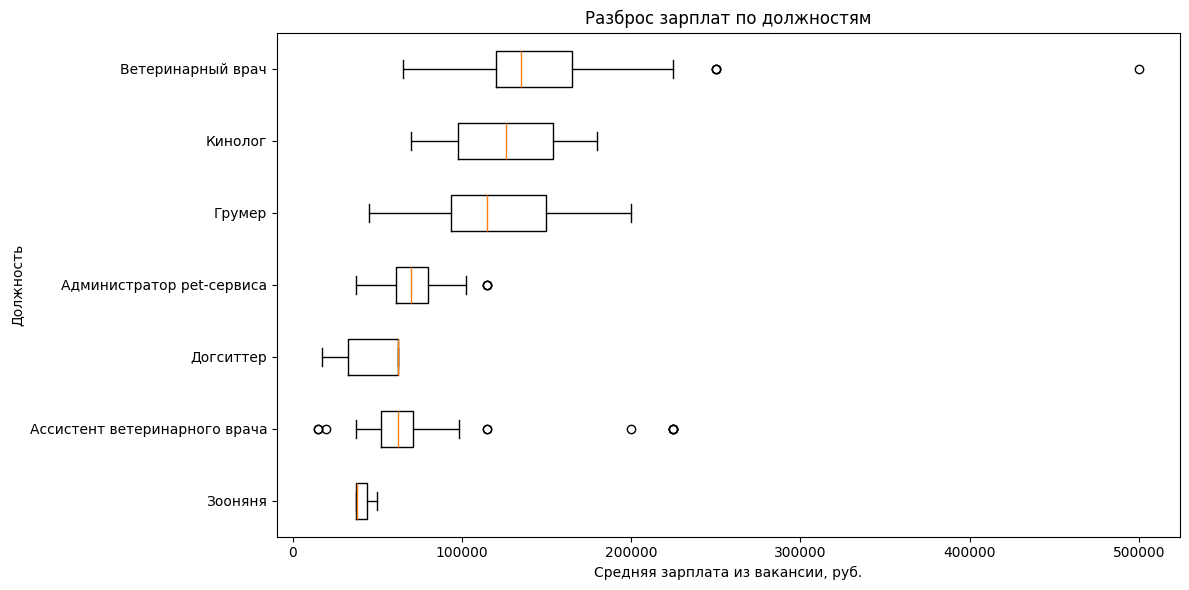

In [24]:
positions = (df.groupby("position")["salary_avg_rub"].median().sort_values().index)

data = [df[df["position"] == position]["salary_avg_rub"] for position in positions]

plt.figure(figsize=(12, 6))
plt.boxplot(data, tick_labels=positions, orientation="horizontal")
plt.title("Разброс зарплат по должностям")
plt.xlabel("Средняя зарплата из вакансии, руб.")
plt.ylabel("Должность")
plt.tight_layout()
plt.show()

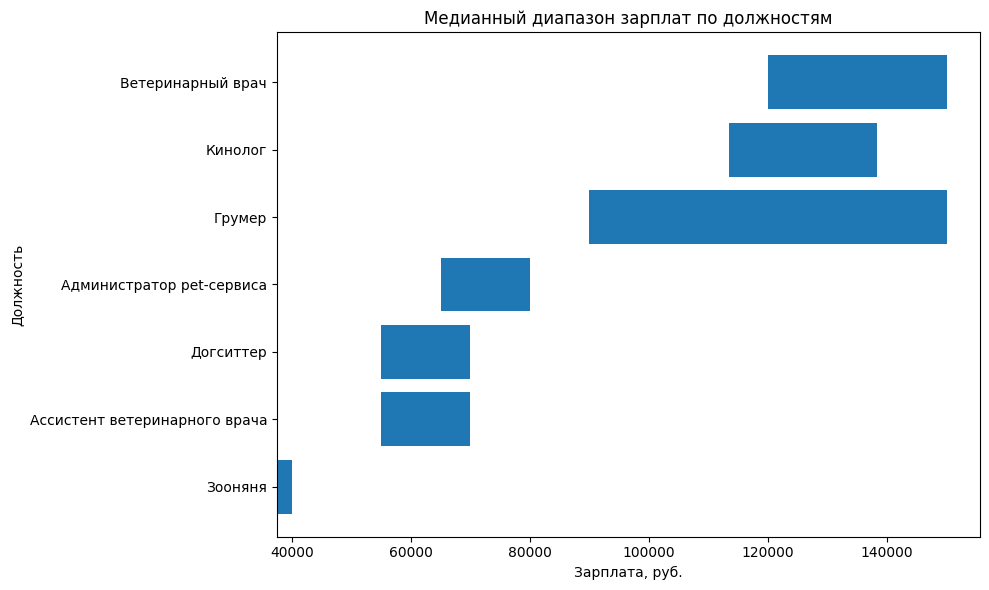

In [26]:
salary_range = (df.groupby("position", as_index=False).agg(salary_min_median=("salary_min_rub", "median"), salary_max_median=("salary_max_rub", "median")))

salary_range["salary_avg_median"] = (salary_range["salary_min_median"] + salary_range["salary_max_median"]) / 2

salary_range = salary_range.sort_values("salary_avg_median", ascending=True)

plt.figure(figsize=(10, 6))

plt.barh(salary_range["position"], salary_range["salary_max_median"] - salary_range["salary_min_median"], left=salary_range["salary_min_median"])

plt.title("Медианный диапазон зарплат по должностям")
plt.xlabel("Зарплата, руб.")
plt.ylabel("Должность")
plt.tight_layout()
plt.show()

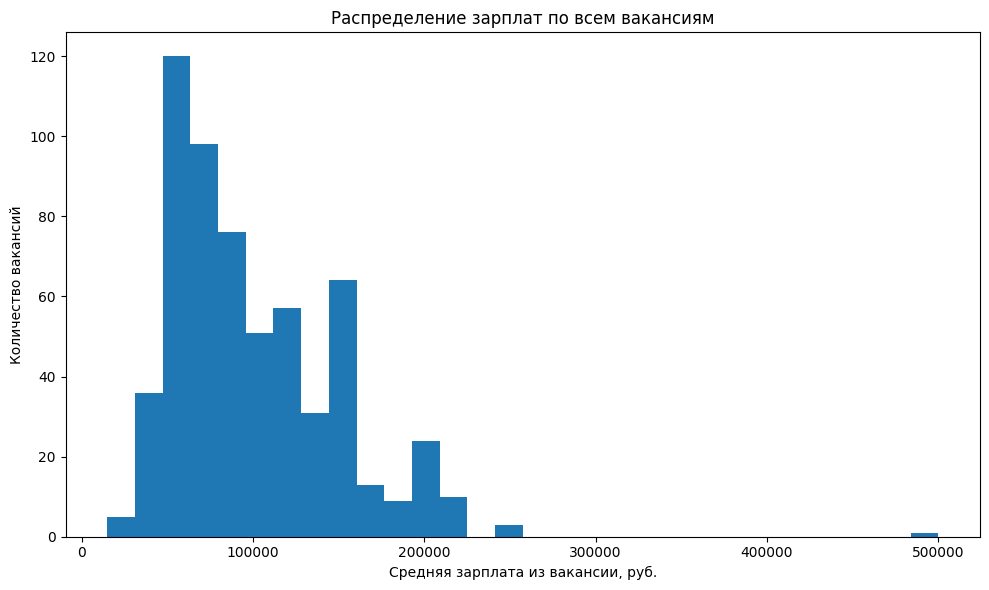

In [27]:
plt.figure(figsize=(10, 6))
plt.hist(df["salary_avg_rub"], bins=30)
plt.title("Распределение зарплат по всем вакансиям")
plt.xlabel("Средняя зарплата из вакансии, руб.")
plt.ylabel("Количество вакансий")
plt.tight_layout()
plt.show()

**Вывод:** На рынке больше всего вакансий для ассистентов ветеринарного врача, ветеринарных врачей, грумеров и администраторов. Самыми дорогими сотрудниками являются ветеринарные врачи и грумеры, а наиболее массовыми - ассистенты и администраторы. Для расчета зарплаты лучше брать медиану, а не среднее, так как медиана меньше искажается очень высокими или очень низкими вакансиями, а по графикам видно, что у ключевых специалистов разброс оплаты достаточно высокий.

# Итоговая зарплата сотрудников

Сделаем таблицу с зарплатой наших будущих сотрудников на основе анализа вакансий.

In [30]:
df = filtered_df.copy()

df["salary_avg_rub"] = (df["salary_min_rub"] + df["salary_max_rub"]) / 2

salary_table = (df.groupby("position", as_index=False).agg(
    vacancies_count=("position", "count"),
    salary_min_median=("salary_min_rub", "median"),
    salary_max_median=("salary_max_rub", "median"),
    recommended_salary_rub=("salary_avg_rub", "median")
    ).sort_values("recommended_salary_rub", ascending=False).reset_index(drop=True))

salary_table[["salary_min_median", "salary_max_median", "recommended_salary_rub"]] = salary_table[["salary_min_median", "salary_max_median", "recommended_salary_rub"]].round(0).astype(int)

print(salary_table)

                        position  vacancies_count  salary_min_median  \
0              Ветеринарный врач              165             120000   
1                        Кинолог                4             113400   
2                         Грумер              124              90000   
3      Администратор pet-сервиса              113              65000   
4  Ассистент ветеринарного врача              182              55000   
5                      Догситтер                7              55000   
6                        Зооняня                3              37500   

   salary_max_median  recommended_salary_rub  
0             150000                  135000  
1             138400                  125900  
2             150000                  115000  
3              80000                   70000  
4              70000                   62500  
5              70000                   62500  
6              40000                   38000  


In [31]:
position_salary_table = salary_table[["position", "recommended_salary_rub"]].copy()

position_salary_table = position_salary_table.rename(columns={"position": "Должность", "recommended_salary_rub": "Рекомендуемая зарплата, руб."})

print(position_salary_table)

position_salary_table.to_csv("position_salary_table.csv", index=False, encoding="utf-8-sig")

                       Должность  Рекомендуемая зарплата, руб.
0              Ветеринарный врач                        135000
1                        Кинолог                        125900
2                         Грумер                        115000
3      Администратор pet-сервиса                         70000
4  Ассистент ветеринарного врача                         62500
5                      Догситтер                         62500
6                        Зооняня                         38000


# Считаем косты, учитывая бенефиты

📊***Какой соцпакет ждут россияне от работодателя?*** *(по исследованию rabota.ru)*


---



In [33]:
URL = "https://press.rabota.ru/43-rossiyan-zhdut-rasshireniya-sotspaketa-ot-rabotodateley"

headers = {"User-Agent": ("Mozilla/5.0 (Windows NT 10.0; Win64; x64) AppleWebKit/537.36 (KHTML, like Gecko) Chrome/124.0 Safari/537.36")}

response = requests.get(URL, headers=headers)
response.raise_for_status()

soup = BeautifulSoup(response.text, "lxml")

page_text = soup.get_text("\n", strip=True)
page_text = page_text.strip()

start_marker = "Какие опции вам нужнее всего в соцпакете? (Множественный выбор)"
start_index = page_text.find(start_marker)

table_text = page_text[start_index + len(start_marker):]

end_marker = "Работа.ру — сервис"

end_position = table_text.find(end_marker)

table_text = table_text[:end_position]

pattern = re.compile(r"(?P<option>[^;%]+?)\s*;\s*(?P<percent>\d+)\s*%", re.IGNORECASE)

rows = []

for match in pattern.finditer(table_text):
    option = match.group("option").strip()
    percent = int(match.group("percent"))

    rows.append({"benefit_option": option, "percent": percent})

benefits_df = pd.DataFrame(rows)

benefits_df = benefits_df.sort_values(by="percent", ascending=False).reset_index(drop=True)

print(benefits_df)

benefits_df.to_csv("rabota_ru_benefits_survey.csv", index=False, encoding="utf-8-sig")

                                       benefit_option  percent
0                         Медицинская страховка (ДМС)       71
1                             Годовые бонусы и премии       65
2                   Компенсация транспортных расходов       48
3                 Дополнительные дни отдыха (day off)       36
4             Компенсация расходов на мобильную связь       32
5                                Корпоративная пенсия       27
6                                Компенсация обучения       25
7                                    Льготная ипотека       25
8   Скидки на товары и услуги компании для сотрудн...       23
9                         Доступ к курсам и тренингам       22
10                      Скидки на фитнес или спортзал       22
11                              Льготное кредитование       18
12                          Психологическая поддержка       14
13                          Корпоративный детский сад        6
14                                             Другое  

✅Возьмем 5 самых популярных вариантов среди респондентов и посчитаем их стоимость:


*   Медицинская страховка (ДМС)
*   Годовые бонусы и премии
* Компенсация транспортных расходов
* Дополнительные дни отдыха (day off)
* Компенсация расходов на мобильную связь


---

Данные для расчета:

1.   Согласно ТАСС, в 2025 году средняя страховая премия на одного застрахованного составила 9,4 тыс. рублей. (https://tass.ru/ekonomika/26728065)
2. Будем считать, что годовая премия составляет месячный оклад, т.е. стоимость для работодателя - 1/12 зп в месяц.
3. Московский транспорт: билет "Единый" на 30 дней стоит 3 460 руб. (https://mosmetro.ru/payment/tickets/troyka)
4. Допустим, мы предостовляем 3 дополнительных оплачиваемых выходных. Тогда, если считать, что в месяце в среднем 22 рабочих дня, месячная стоимость доп. выходных = salary/22×3/12
5. Корпоративные тарифы Билайн: тариф "ПроБизнес S" - 510 руб/мес. (https://moskva.beeline.ru/business/mobile-and-internet/mobile/)



---

Теперь посчитаем общую стоимость бенефитов. Не забываем про единый страховой взнос для работодателей, который составляет 30% от зарплаты.







In [34]:
def benefits_per_month(salary):
  insurance = 9400 / 12
  bonus = (1 / 12) * salary
  transport = 3460
  cell_service = 510
  days_off = ((salary * 1.3) / 22) * (3 / 12)

  benefits = sum([insurance, bonus, transport, cell_service, days_off])
  return round(benefits, 2)

Наконец, посчитаем total cost, предполагая, что мы нанимаем по одному сотруднику для каждой должности.

In [35]:
full_salary_table = salary_table[["position", "recommended_salary_rub"]].copy()

full_salary_table["benefits_per_month_rub"] = full_salary_table["recommended_salary_rub"].apply(benefits_per_month)

full_salary_table["insurance_contributions_rub"] = (full_salary_table["recommended_salary_rub"] * 0.30)

full_salary_table["total_cost_rub"] = (full_salary_table["recommended_salary_rub"] + full_salary_table["insurance_contributions_rub"] + full_salary_table["benefits_per_month_rub"])

full_salary_table = full_salary_table.sort_values("total_cost_rub", ascending=False).reset_index(drop=True)

print(full_salary_table)

                        position  recommended_salary_rub  \
0              Ветеринарный врач                  135000   
1                        Кинолог                  125900   
2                         Грумер                  115000   
3      Администратор pet-сервиса                   70000   
4  Ассистент ветеринарного врача                   62500   
5                      Догситтер                   62500   
6                        Зооняня                   38000   

   benefits_per_month_rub  insurance_contributions_rub  total_cost_rub  
0                17997.65                      40500.0       193497.65  
1                17104.89                      37770.0       180774.89  
2                16035.53                      34500.0       165535.53  
3                11620.76                      21000.0       102620.76  
4                10884.96                      18750.0        92134.96  
5                10884.96                      18750.0        92134.96  
6       

In [36]:
total_team_cost = full_salary_table["total_cost_rub"].sum()

print("Total cost команды в месяц:", total_team_cost)

full_salary_table.to_csv("total_cost_by_position.csv", index=False, encoding="utf-8-sig")

Total cost команды в месяц: 884580.11


✅Итого, если нанять по одному сотруднику каждой должности, total cost составит **884 580 рублей в месяц**.